# ***A Machine Learning Approach to Predicting Late Delivery Risk in Supply Chain Logistics***

## ***Problem Statement***

Late deliveries represent a critical operational challenge in modern supply chain management, often resulting in increased costs, reduced customer satisfaction, and inefficiencies in logistics planning. Although organizations collect extensive operational data covering shipment performance, product characteristics, customer information, and sales activity, they frequently struggle to identify orders at risk of delay before fulfillment is complete. The DataCo Supply Chain Dataset offers a realistic view of these operations, capturing a broad mix of categorical and numeric variables that influence delivery outcomes and providing a strong foundation for predictive analysis.

This project investigates whether late delivery risk can be accurately predicted using order, shipment, product, and customer related variables, and seeks to identify the factors that contribute most significantly to delays, including shipping mode, scheduled shipping days, market, order region, customer segment, and product category. The study further examines whether particular shipping modes, markets, or order regions experience disproportionately higher levels of late delivery risk, and evaluates which machine learning model delivers the strongest predictive performance, ultimately enabling earlier detection of operational risk and informed decisions in logistics management.

***Source:*** https://www.kaggle.com/datasets/evilspirit05/datasupplychain

## ***Dataset Dictionary***

***Data Dictionary of DataCo Supply Chain Dataset***

| # | Variable | Description |
|---|----------|-------------|
| 0 | Type | Type of payment or transaction (e.g., DEBIT, CASH, TRANSFER, PAYMENT) |
| 1 | Days for shipping (real) | Actual number of days taken for shipment |
| 2 | Days for shipment (scheduled) | Scheduled number of days for shipment |
| 3 | Benefit per order | Profit earned per order |
| 4 | Sales per customer | Total sales generated per customer |
| 5 | Delivery Status | Delivery outcome (e.g., Advance shipping, Late delivery, Shipping on time, Shipping canceled) |
| 6 | Late_delivery_risk | Target variable: binary indicator (1 = late delivery, 0 = on time) |
| 7 | Category Id | Identifier for the product category |
| 8 | Category Name | Name of the product category |
| 9 | Customer City | City where the customer is located |
| 10 | Customer Country | Country of the customer |
| 11 | Customer Email | Customer's email address (anonymized) |
| 12 | Customer Fname | Customer's first name |
| 13 | Customer Id | Unique identifier for the customer |
| 14 | Customer Lname | Customer's last name |
| 15 | Customer Password | Customer's password (anonymized) |
| 16 | Customer Segment | Segment classification (e.g., Consumer, Corporate, Home Office) |
| 17 | Customer State | State or region of the customer |
| 18 | Customer Street | Street address of the customer |
| 19 | Customer Zipcode | Customer's postal code |
| 20 | Department Id | Identifier for the product department |
| 21 | Department Name | Name of the product department |
| 22 | Latitude | Latitude coordinate of the order or customer location |
| 23 | Longitude | Longitude coordinate of the order or customer location |
| 24 | Market | Market region (e.g., Africa, Europe, LATAM, Pacific Asia, USCA) |
| 25 | Order City | City where the order was placed |
| 26 | Order Country | Country where the order was placed |
| 27 | Order Customer Id | Customer ID linked to the order |
| 28 | order date (DateOrders) | Date the order was placed |
| 29 | Order Id | Unique identifier for each order |
| 30 | Order Item Cardprod Id | Product card ID associated with the order item |
| 31 | Order Item Discount | Discount amount applied to the order item |
| 32 | Order Item Discount Rate | Discount rate applied to the order item |
| 33 | Order Item Id | Unique identifier for each order item |
| 34 | Order Item Product Price | Price of the product in the order item |
| 35 | Order Item Profit Ratio | Profit ratio of the order item |
| 36 | Order Item Quantity | Quantity of items ordered |
| 37 | Sales | Total sales value of the order |
| 38 | Order Item Total | Total value of the order item after discounts |
| 39 | Order Profit Per Order | Net profit generated per order |
| 40 | Order Region | Geographic region of the order |
| 41 | Order State | State of the order |
| 42 | Order Status | Current status of the order (e.g., Complete, Pending, Canceled) |
| 43 | Order Zipcode | Postal code of the order destination |
| 44 | Product Card Id | Unique product card identifier |
| 45 | Product Category Id | Identifier linking product to its category |
| 46 | Product Description | Description of the product |
| 47 | Product Image | URL or reference to the product image |
| 48 | Product Name | Name of the product |
| 49 | Product Price | Listed price of the product |
| 50 | Product Status | Status indicator of the product (e.g., available, discontinued) |
| 51 | shipping date (DateOrders) | Date the order was shipped |
| 52 | Shipping Mode | Mode of shipment (e.g., Standard Class, First Class, Second Class, Same Day) |



## ***Import the required libraries***

In [ ]:
# Import core libraries for numerical operations and data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import tools for splitting data and hyperparameter tuning
from sklearn.model_selection import train_test_split
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
)

# Import scaler for standardizing numerical features
from sklearn.preprocessing import StandardScaler

# Import SMOTE to handle class imbalance through oversampling
from imblearn.over_sampling import SMOTE

# Import machine learning classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import model evaluation metrics
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# Suppress warning messages to keep notebook output clean
import warnings
warnings.filterwarnings('ignore')

## ***Load the dataset into the python notebook***

In [ ]:
!pip install kagglehub

import kagglehub
import os

path = kagglehub.dataset_download('evilspirit05/datasupplychain')

print('Path to dataset files:', path)
print('Files in the dataset:', os.listdir(path))

df = pd.read_csv(os.path.join(path, 'DataCoSupplyChainDataset.csv'), encoding = 'latin-1')

Using Colab cache for faster access to the 'datasupplychain' dataset.
Path to dataset files: /kaggle/input/datasupplychain
Files in the dataset: ['DataCoSupplyChainDataset.csv']


In [ ]:
delivery_df = df.copy()

## ***Overview of the dataset***

### ***View the first five rows of the dataset***

In [ ]:
delivery_df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


### ***View the last five rows of the dataset***

In [ ]:
delivery_df.tail()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,EE. UU.,XXXXXXXXX,Maria,1005,Peterson,XXXXXXXXX,Home Office,NY,1322 Broad Glade,11207.0,7,Fan Shop,40.640930,-73.942711,Pacific Asia,Shanghái,China,1005,1/16/2016 3:40,26043,1004,0.0,0.00,65177,399.980011,0.10,1,399.980011,399.980011,40.000000,Eastern Asia,Shanghái,CLOSED,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,EE. UU.,XXXXXXXXX,Ronald,9141,Clark,XXXXXXXXX,Corporate,CA,7330 Broad Apple Moor,93304.0,7,Fan Shop,35.362545,-119.018700,Pacific Asia,Hirakata,Japón,9141,1/16/2016 1:34,26037,1004,4.0,0.01,65161,399.980011,-1.55,1,399.980011,395.980011,-613.770019,Eastern Asia,Osaka,COMPLETE,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,EE. UU.,XXXXXXXXX,John,291,Smith,XXXXXXXXX,Corporate,CT,97 Burning Landing,6010.0,7,Fan Shop,41.629959,-72.967155,Pacific Asia,Adelaide,Australia,291,1/15/2016 21:00,26024,1004,8.0,0.02,65129,399.980011,0.36,1,399.980011,391.980011,141.110001,Oceania,Australia del Sur,PENDING,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Mary,2813,Smith,XXXXXXXXX,Consumer,PR,2585 Silent Autumn Landing,725.0,7,Fan Shop,18.213350,-66.370575,Pacific Asia,Adelaide,Australia,2813,1/15/2016 20:18,26022,1004,12.0,0.03,65126,399.980011,0.48,1,399.980011,387.980011,186.229996,Oceania,Australia del Sur,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class
180518,PAYMENT,4,4,168.949997,383.980011,Shipping on time,0,45,Fishing,Caguas,Puerto Rico,XXXXXXXXX,Andrea,7547,Ortega,XXXXXXXXX,Consumer,PR,697 Little Meadow,725.0,7,Fan Shop,18.290380,-66.370613,Pacific Asia,Nagercoil,India,7547,1/15/2016 18:54,26018,1004,16.0,0.04,65113,399.980011,0.44,1,399.980011,383.980011,168.949997,South Asia,Tamil Nadu,PENDING_PAYMENT,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 18:54,Standard Class


### ***View the dimensions of the dataset***

In [ ]:
delivery_df.shape

(180519, 53)

### ***Check the datatype of each column in the dataset***

In [ ]:
delivery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Email                 180519 non-null  object 
 12  Customer Fname                

### ***Feature Selection for Late Delivery Risk Prediction***

In [ ]:
selected_features = [
    'Type',
    'Days for shipment (scheduled)',
    'Shipping Mode',
    'Category Name',
    'Department Name',
    'Customer Segment',
    'Customer Country',
    'Market',
    'Order Region',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Product Price',
]

target_variable = 'Late_delivery_risk'

delivery_df = delivery_df[selected_features + [target_variable]]

### ***View the first five rows of the dataset after feature selection***

In [ ]:
delivery_df.head()

,Type,Days for shipment (scheduled),Shipping Mode,Category Name,Department Name,Customer Segment,Customer Country,Market,Order Region,Order Item Quantity,Order Item Discount Rate,Product Price,Late_delivery_risk
0,DEBIT,4,Standard Class,Sporting Goods,Fitness,Consumer,Puerto Rico,Pacific Asia,Southeast Asia,1,0.04,327.75,0
1,TRANSFER,4,Standard Class,Sporting Goods,Fitness,Consumer,Puerto Rico,Pacific Asia,South Asia,1,0.05,327.75,1
2,CASH,4,Standard Class,Sporting Goods,Fitness,Consumer,EE. UU.,Pacific Asia,South Asia,1,0.06,327.75,0
3,DEBIT,4,Standard Class,Sporting Goods,Fitness,Home Office,EE. UU.,Pacific Asia,Oceania,1,0.07,327.75,0
4,PAYMENT,4,Standard Class,Sporting Goods,Fitness,Corporate,Puerto Rico,Pacific Asia,Oceania,1,0.09,327.75,0


### ***View the last five rows of the dataset after feature selection***

In [ ]:
delivery_df.tail()

,Type,Days for shipment (scheduled),Shipping Mode,Category Name,Department Name,Customer Segment,Customer Country,Market,Order Region,Order Item Quantity,Order Item Discount Rate,Product Price,Late_delivery_risk
180514,CASH,4,Standard Class,Fishing,Fan Shop,Home Office,EE. UU.,Pacific Asia,Eastern Asia,1,0.00,399.980011,0
180515,DEBIT,2,Second Class,Fishing,Fan Shop,Corporate,EE. UU.,Pacific Asia,Eastern Asia,1,0.01,399.980011,1
180516,TRANSFER,4,Standard Class,Fishing,Fan Shop,Corporate,EE. UU.,Pacific Asia,Oceania,1,0.02,399.980011,1
180517,PAYMENT,4,Standard Class,Fishing,Fan Shop,Consumer,Puerto Rico,Pacific Asia,Oceania,1,0.03,399.980011,0
180518,PAYMENT,4,Standard Class,Fishing,Fan Shop,Consumer,Puerto Rico,Pacific Asia,South Asia,1,0.04,399.980011,0


### ***View the last five rows of the dataset after feature selection***

In [ ]:
delivery_df.shape

(180519, 13)

### ***Check the datatype of each column in the dataset after feature selection***

In [ ]:
delivery_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Shipping Mode                  180519 non-null  object 
 3   Category Name                  180519 non-null  object 
 4   Department Name                180519 non-null  object 
 5   Customer Segment               180519 non-null  object 
 6   Customer Country               180519 non-null  object 
 7   Market                         180519 non-null  object 
 8   Order Region                   180519 non-null  object 
 9   Order Item Quantity            180519 non-null  int64  
 10  Order Item Discount Rate       180519 non-null  float64
 11  Product Price                  180519 non-null  float64
 12  Late_delivery_risk            

## ***Initial sanity checks of the dataset***

### ***Check if there are any duplicate values in the dataset***

In [ ]:
delivery_df.duplicated().sum()

np.int64(30561)

### ***Drop the duplicated records in the dataset***

In [ ]:
delivery_df.drop_duplicates(inplace = True)

In [ ]:
delivery_df.shape

(149958, 13)

### ***Check if there are any missing values in the dataset***

In [ ]:
delivery_df.isnull().sum()

,0
Type,0
Days for shipment (scheduled),0
Shipping Mode,0
Category Name,0
Department Name,0
Customer Segment,0
Customer Country,0
Market,0
Order Region,0
Order Item Quantity,0


## ***Exploratory Data Analysis (EDA)***

### ***Check the statistical summary of Numerical Variables***

In [ ]:
delivery_df.describe(include = 'number').T

,count,mean,std,min,25%,50%,75%,max
Days for shipment (scheduled),149958.0,2.840342,1.402764,0.00,2.00,4.000000,4.000000,4.00000
Order Item Quantity,149958.0,2.240041,1.477727,1.00,1.00,1.000000,3.000000,5.00000
Order Item Discount Rate,149958.0,0.101717,0.070459,0.00,0.04,0.100000,0.160000,0.25000
Product Price,149958.0,131.369419,139.811327,9.99,49.98,59.990002,199.990005,1999.98999
Late_delivery_risk,149958.0,0.566779,0.495522,0.00,0.00,1.000000,1.000000,1.00000


### ***Check the statistical summary of Categorical Variables***

In [ ]:
delivery_df.describe(include = 'object').T

,count,unique,top,freq
Type,149958,4,DEBIT,54840
Shipping Mode,149958,4,Standard Class,84683
Category Name,149958,50,Cleats,21497
Department Name,149958,11,Fan Shop,51357
Customer Segment,149958,3,Consumer,73990
Customer Country,149958,2,EE. UU.,90126
Market,149958,5,Europe,40057
Order Region,149958,23,Western Europe,19842


### ***Feature Engineering***

In [ ]:
top_categories = delivery_df['Category Name'].value_counts().nlargest(10).index
delivery_df['Category Name'] = delivery_df['Category Name'].apply(lambda x: x if x in top_categories else 'Other')

In [ ]:
delivery_df['Category Name'].value_counts(normalize = True) * 100

,proportion
Category Name,
Cleats,14.335347
Other,13.193027
Women's Apparel,12.520172
Indoor/Outdoor Games,11.577908
Men's Footwear,9.564011
Fishing,7.941557
Cardio Equipment,7.765508
Water Sports,7.378066
Shop By Sport,6.903933


### ***Mapping the Target Variable for EDA Clarity***

In [ ]:
delivery_df['Delivery_outcome'] = delivery_df['Late_delivery_risk'].map({0: 'On Time', 1: 'Late'})

### ***Identify Numerical and Categorical Variables***

In [ ]:
numerical_columns = delivery_df.select_dtypes(include = 'number').columns.drop('Late_delivery_risk')
categorical_columns = delivery_df.select_dtypes(include = 'object').columns

### ***Display each unique category in the Categorical Variables***

In [ ]:
for col in categorical_columns:
  print(f'{col}: {delivery_df[col].unique()}')

Type: ['DEBIT' 'TRANSFER' 'CASH' 'PAYMENT']
Shipping Mode: ['Standard Class' 'First Class' 'Second Class' 'Same Day']
Category Name: ['Other' 'Cleats' 'Shop By Sport' "Women's Apparel" 'Electronics'
 'Cardio Equipment' "Men's Footwear" 'Camping & Hiking' 'Fishing'
 'Water Sports' 'Indoor/Outdoor Games']
Department Name: ['Fitness' 'Apparel' 'Golf' 'Footwear' 'Outdoors' 'Fan Shop' 'Technology'
 'Book Shop' 'Discs Shop' 'Pet Shop' 'Health and Beauty ']
Customer Segment: ['Consumer' 'Home Office' 'Corporate']
Customer Country: ['Puerto Rico' 'EE. UU.']
Market: ['Pacific Asia' 'USCA' 'Africa' 'Europe' 'LATAM']
Order Region: ['Southeast Asia' 'South Asia' 'Oceania' 'Eastern Asia' 'West Asia'
 'West of USA ' 'US Center ' 'West Africa' 'Central Africa' 'North Africa'
 'Western Europe' 'Northern Europe' 'Central America' 'Caribbean'
 'South America' 'East Africa' 'Southern Europe' 'East of USA' 'Canada'
 'Southern Africa' 'Central Asia' 'Eastern Europe' 'South of  USA ']
Delivery_outcome: ['On

 ### ***Renaming Categories for Clarity***

In [ ]:
delivery_df['Customer Country'] = delivery_df['Customer Country'].replace({'EE. UU.': 'United States'})

### ***Univariate Analysis***

#### ***Histogram of Numerical Variables***

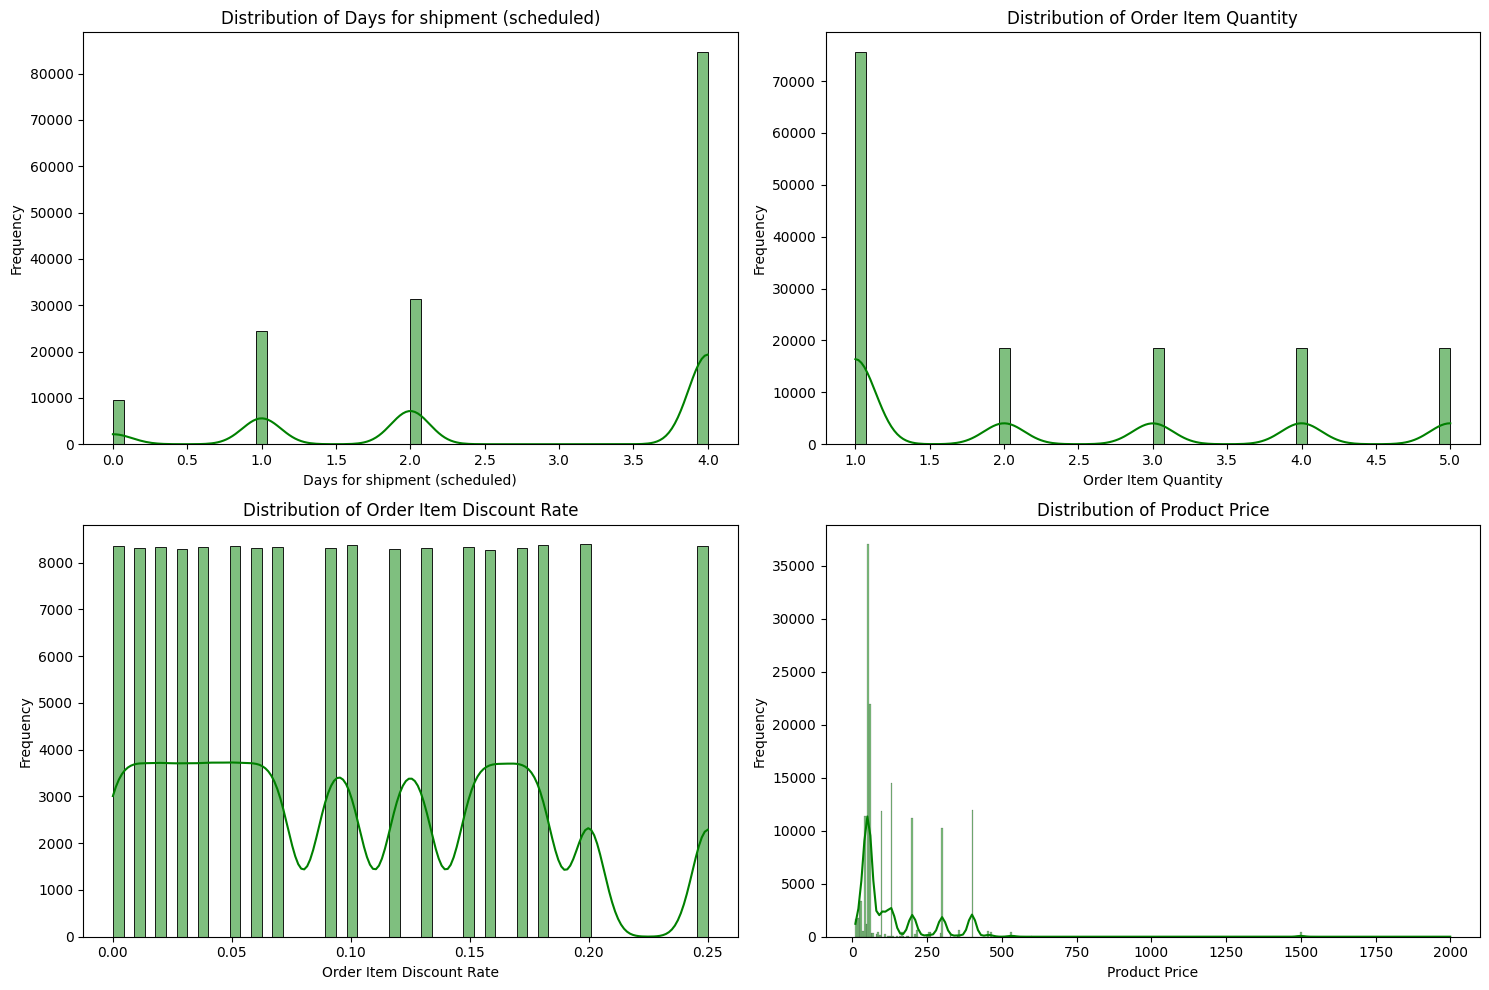

In [ ]:
plt.figure(figsize = (15, 10))

for i, col in enumerate(numerical_columns):
  plt.subplot(2, 2, i + 1)
  sns.histplot(delivery_df[col], kde = True, color = 'Green')
  plt.title(f'Distribution of {col}')
  plt.xlabel(col)
  plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

#### ***Boxplot of Numerical Variables***

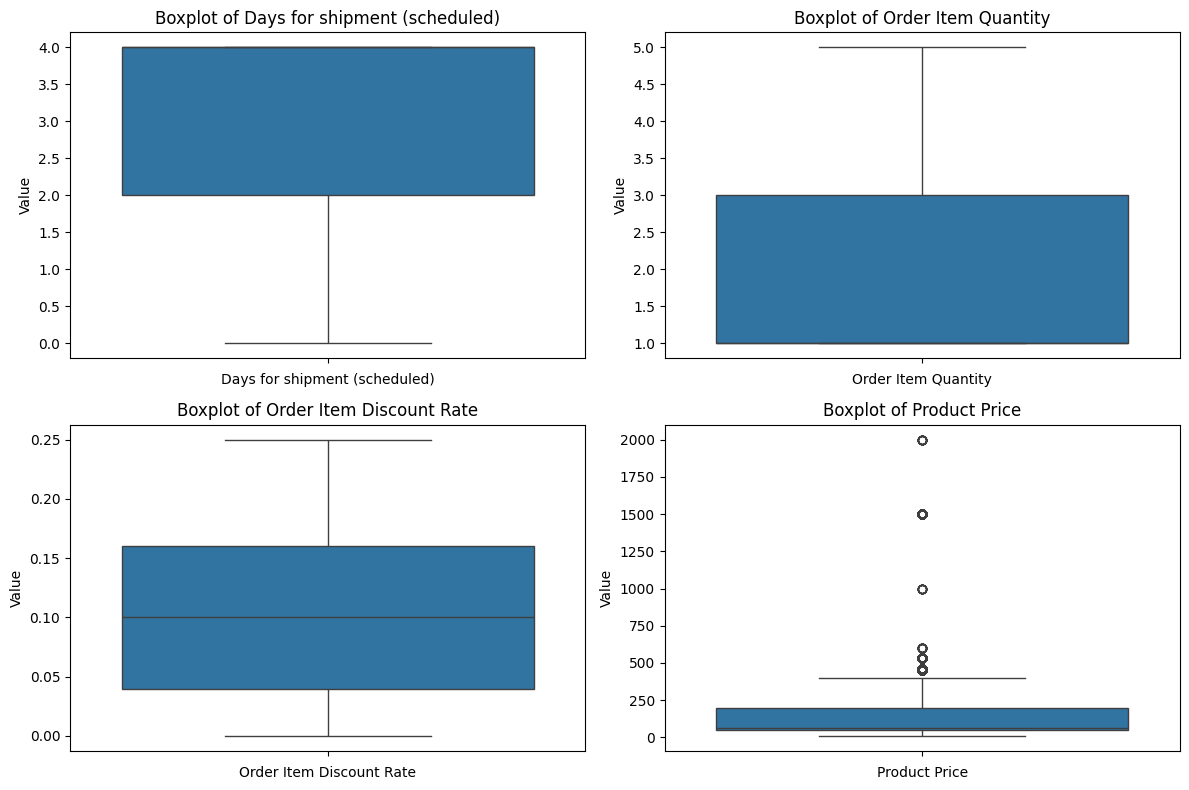

In [ ]:
plt.figure(figsize = (12, 8))

for i, col in enumerate(numerical_columns):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(delivery_df[col])
  plt.title(f'Boxplot of {col}')
  plt.xlabel(col)
  plt.ylabel('Value')

plt.tight_layout()
plt.show()

#### ***Countplot of Categorical Variables and Target Variable***

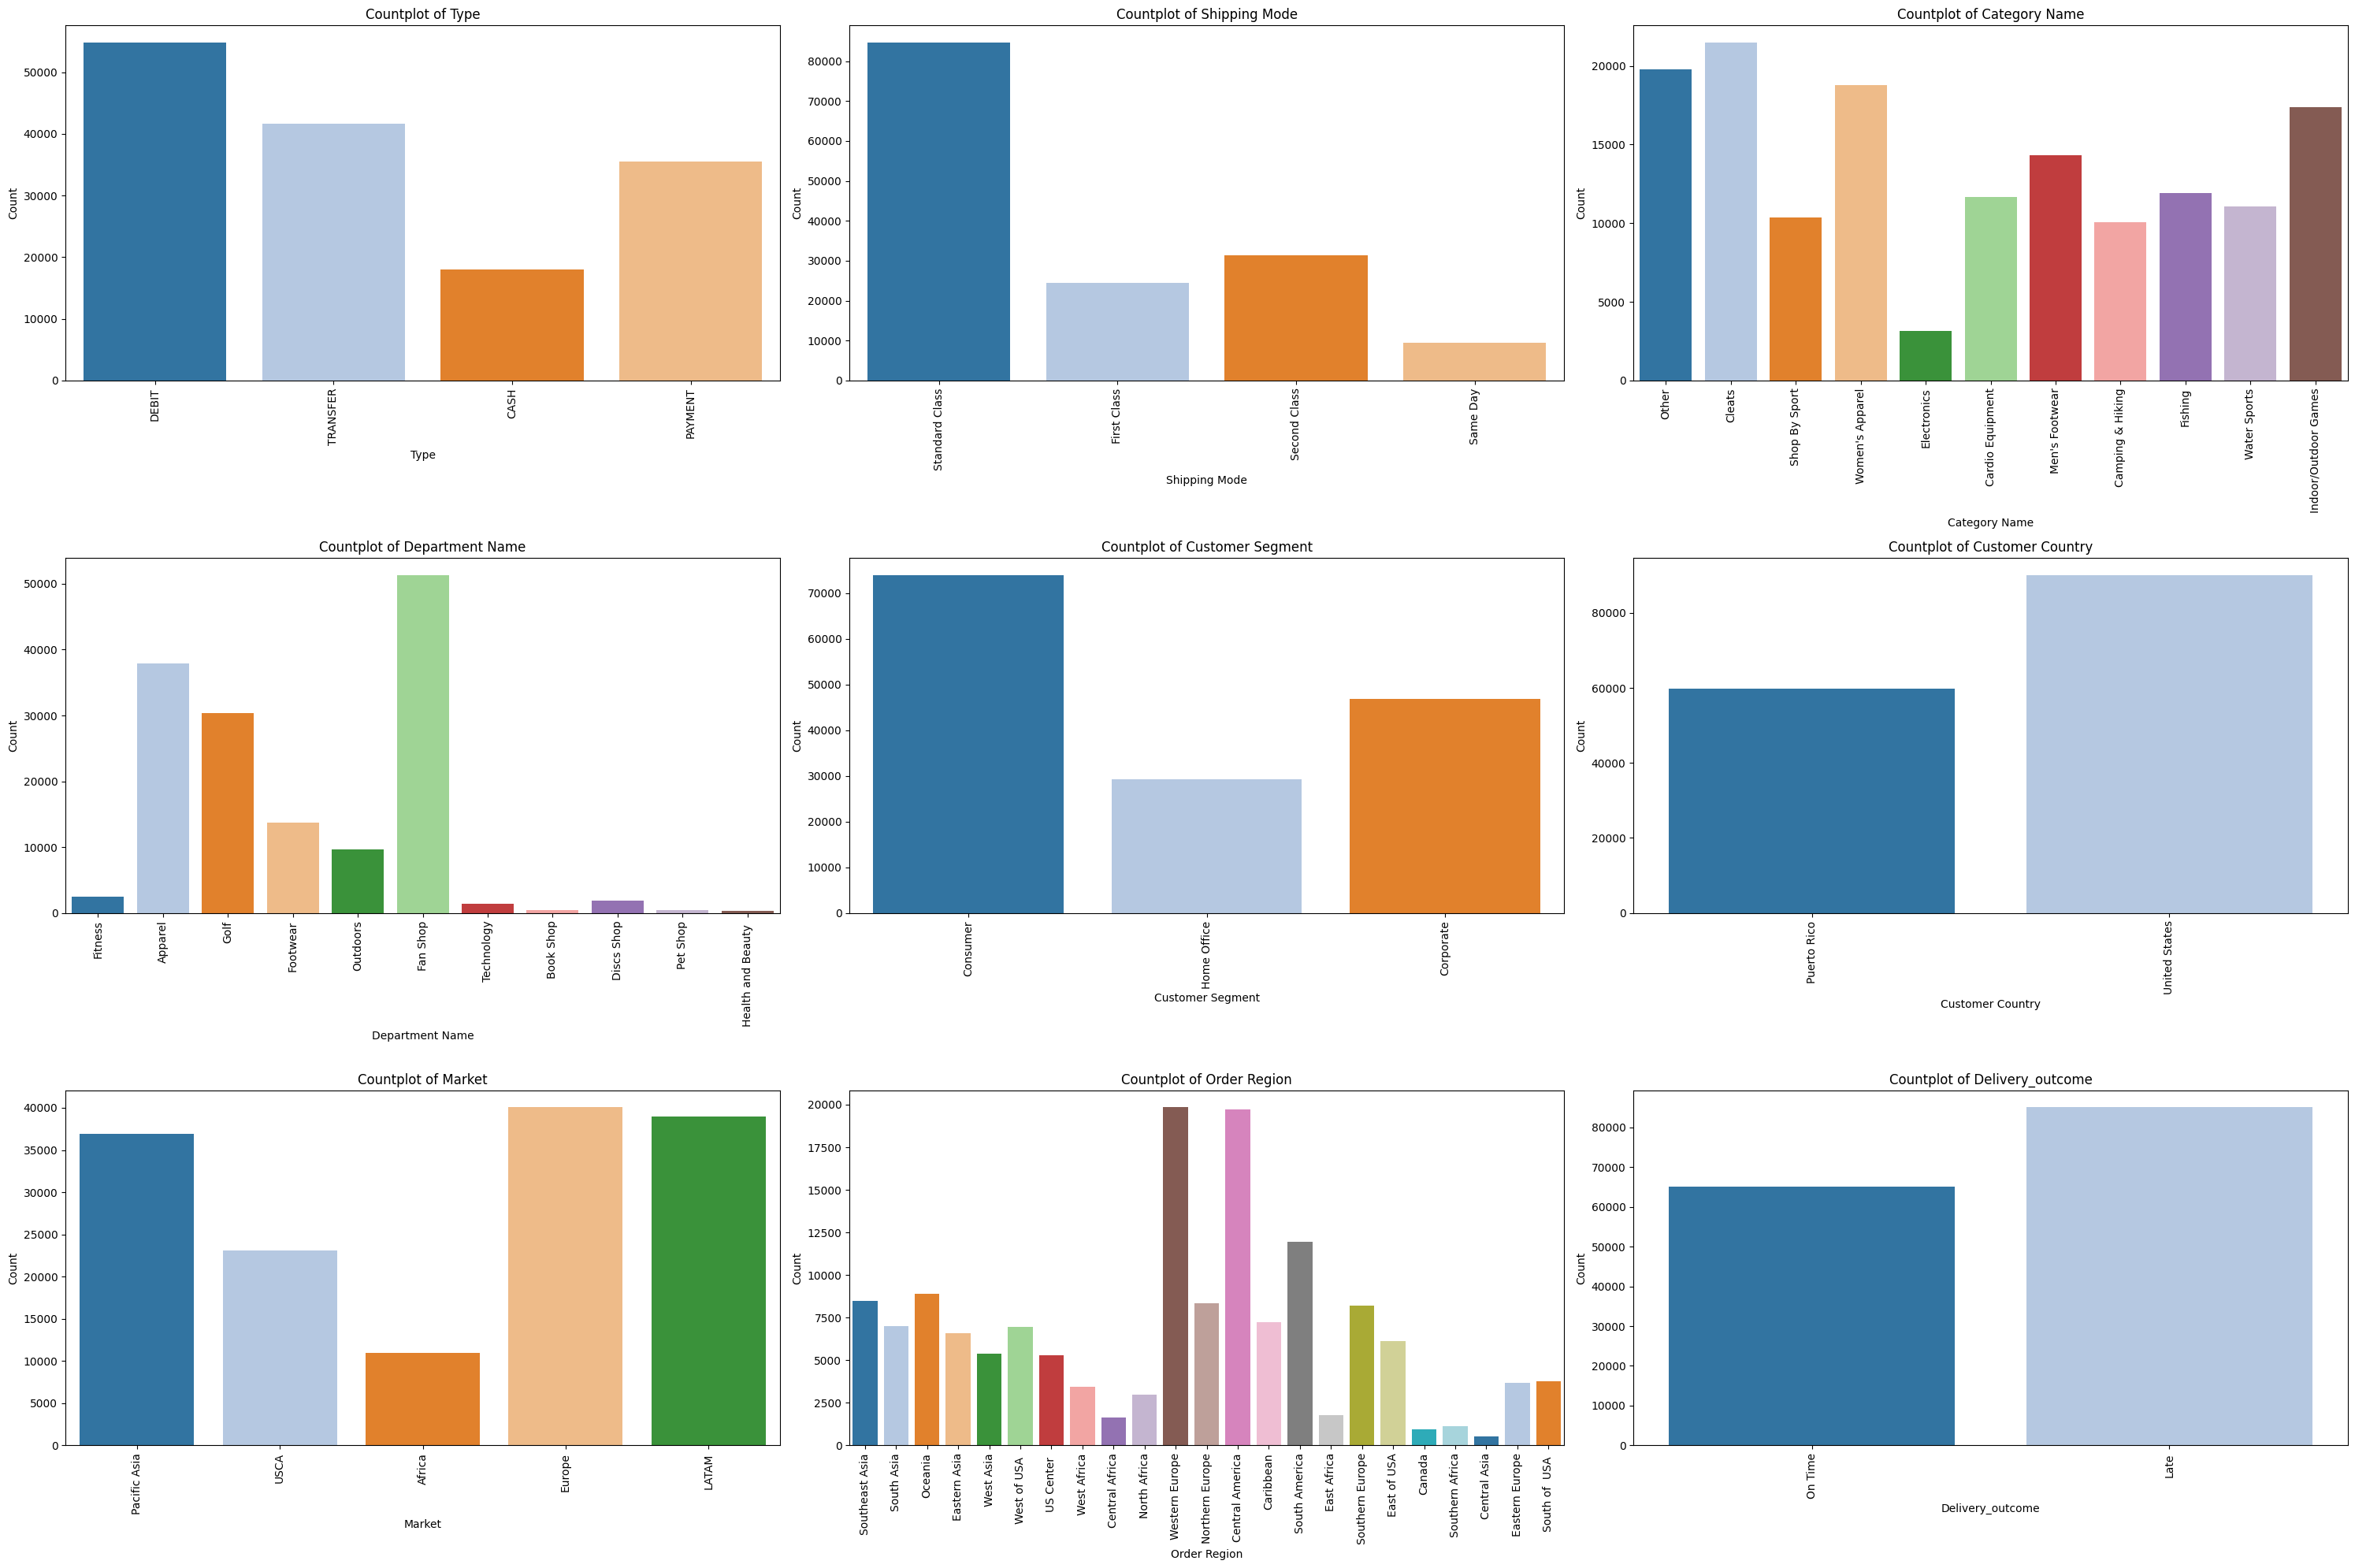

In [ ]:
plt.figure(figsize = (30, 20))

for i, col in enumerate(categorical_columns):
  plt.subplot(3, 3, i + 1)
  sns.countplot(data = delivery_df, x = col, palette = 'tab20')
  plt.title(f'Countplot of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation = 90)

plt.tight_layout()
plt.show()

### ***Bivariate Analysis***

#### ***Pairplot of Numerical Variables***

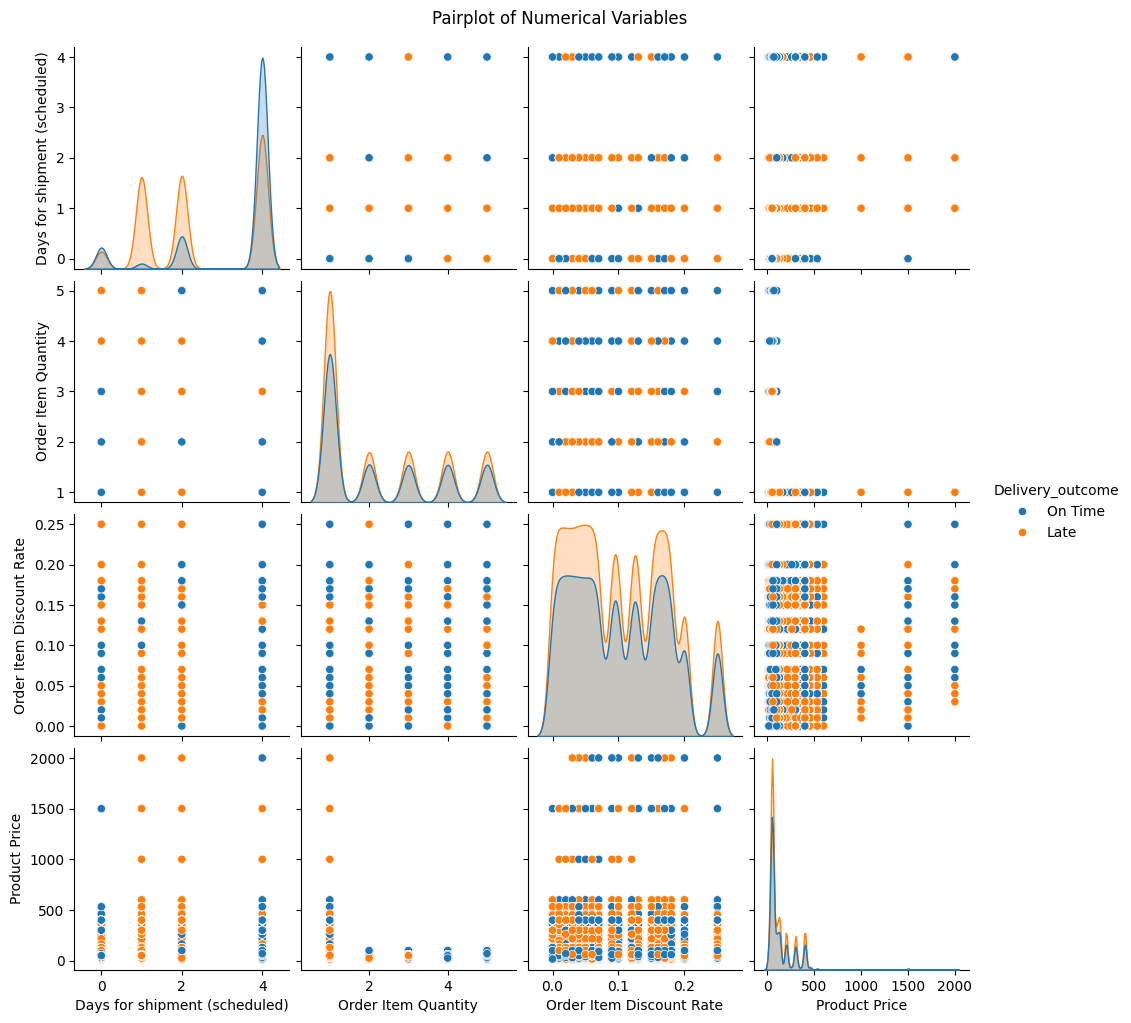

In [ ]:
sns.pairplot(delivery_df, vars = numerical_columns, hue = 'Delivery_outcome', diag_kind = 'kde')
plt.suptitle('Pairplot of Numerical Variables', y = 1.02)
plt.show()

#### ***Boxplots of Numerical Variables by 'Late_delivery_status'***

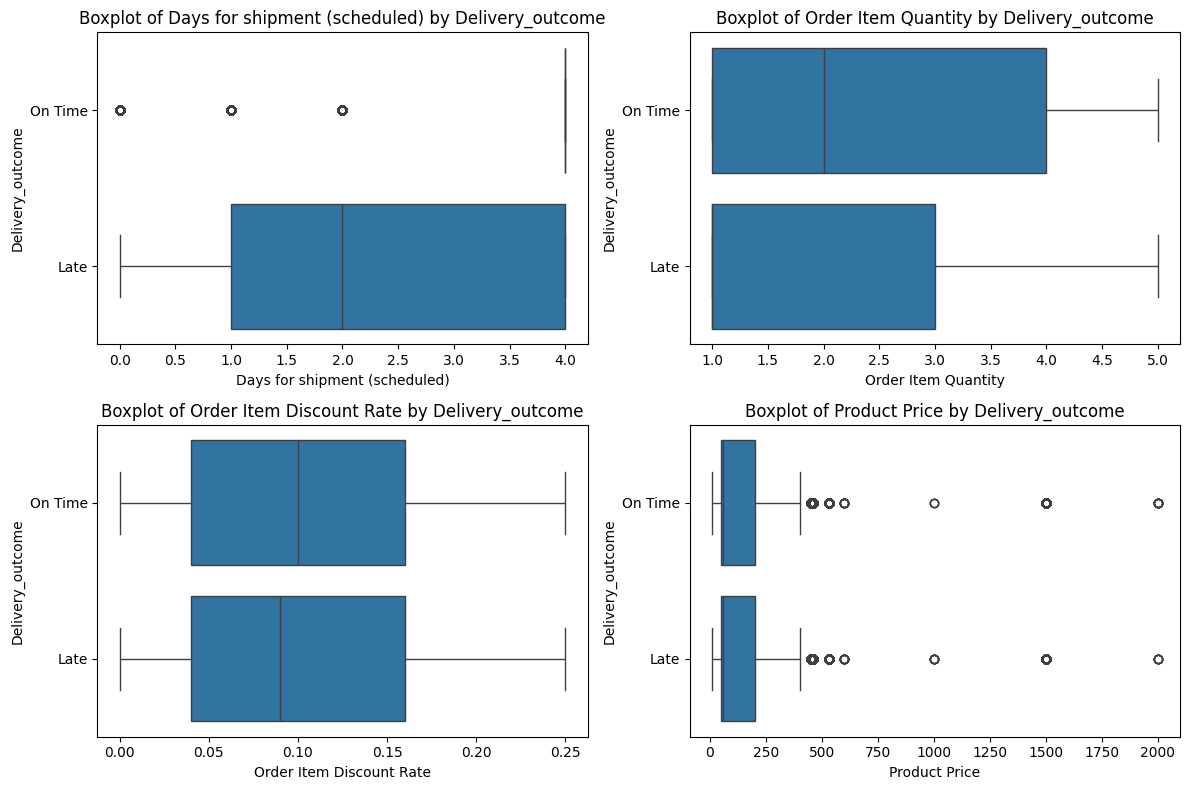

In [ ]:
plt.figure(figsize = (12, 8))

for i, col in enumerate(numerical_columns):
  plt.subplot(2, 2, i + 1)
  sns.boxplot(data = delivery_df, x = col, y = 'Delivery_outcome')
  plt.title(f'Boxplot of {col} by Delivery_outcome')
  plt.xlabel(col)
  plt.ylabel('Delivery_outcome')

plt.tight_layout()
plt.show()

#### ***Stacked Bar Plots of Categorical Variables by Delivery Outcome***

In [ ]:
def stacked_barplot(data, predictor, target):

    """
    Print the category counts and plot a stacked bar chart

    Parameters
    data: dataframe
    predictor: independent variable
    target: target variable
    """

    count = data[predictor].nunique()

    sorter = data[target].value_counts().index[-1]

    tab1 = pd.crosstab(data[predictor], data[target], normalize = 'index').sort_values(
        by = sorter, ascending = False
    )

    print(tab1)
    print('-' * 120)

    tab = pd.crosstab(data[predictor], data[target], normalize = 'index').sort_values(
        by = sorter, ascending = False
    )
    tab.plot(kind = 'bar', stacked = True, figsize = (count + 5, 5))

    plt.legend(loc = 'lower left', frameon = False)
    plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1))

    plt.show()

Delivery_outcome      Late   On Time
Type                                
TRANSFER          0.505994  0.494006
CASH              0.579540  0.420460
PAYMENT           0.587656  0.412344
DEBIT             0.595204  0.404796
------------------------------------------------------------------------------------------------------------------------


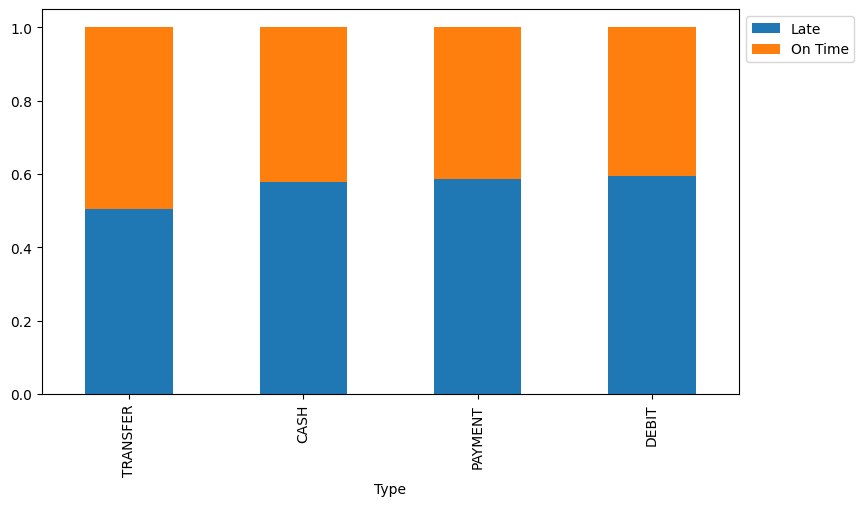

In [ ]:
stacked_barplot(delivery_df, 'Type', 'Delivery_outcome')

Delivery_outcome      Late   On Time
Shipping Mode                       
Standard Class    0.400222  0.599778
Same Day          0.459242  0.540758
Second Class      0.750948  0.249052
First Class       0.948769  0.051231
------------------------------------------------------------------------------------------------------------------------


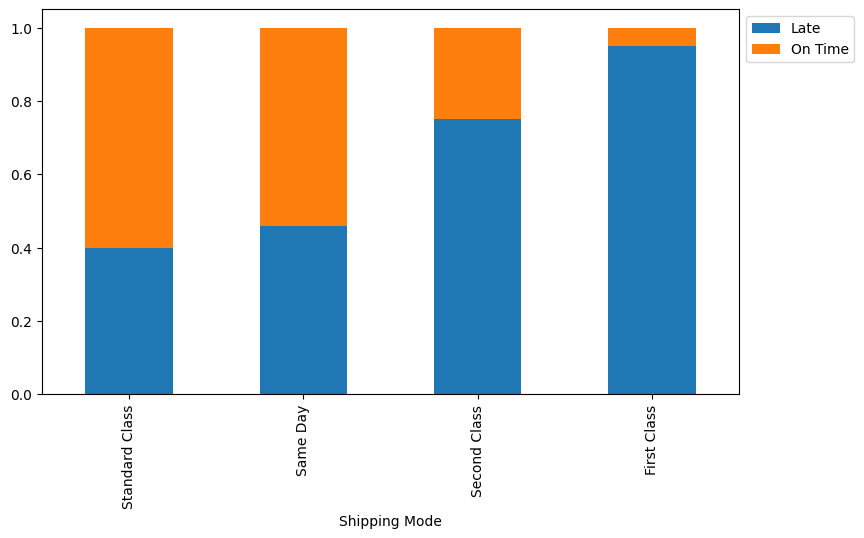

In [ ]:
stacked_barplot(delivery_df, 'Shipping Mode', 'Delivery_outcome')

Delivery_outcome          Late   On Time
Category Name                           
Cardio Equipment      0.555432  0.444568
Other                 0.556611  0.443389
Shop By Sport         0.560031  0.439969
Indoor/Outdoor Games  0.560707  0.439293
Electronics           0.560890  0.439110
Women's Apparel       0.561278  0.438722
Cleats                0.567335  0.432665
Camping & Hiking      0.574390  0.425610
Water Sports          0.577007  0.422993
Fishing               0.582333  0.417667
Men's Footwear        0.583740  0.416260
------------------------------------------------------------------------------------------------------------------------


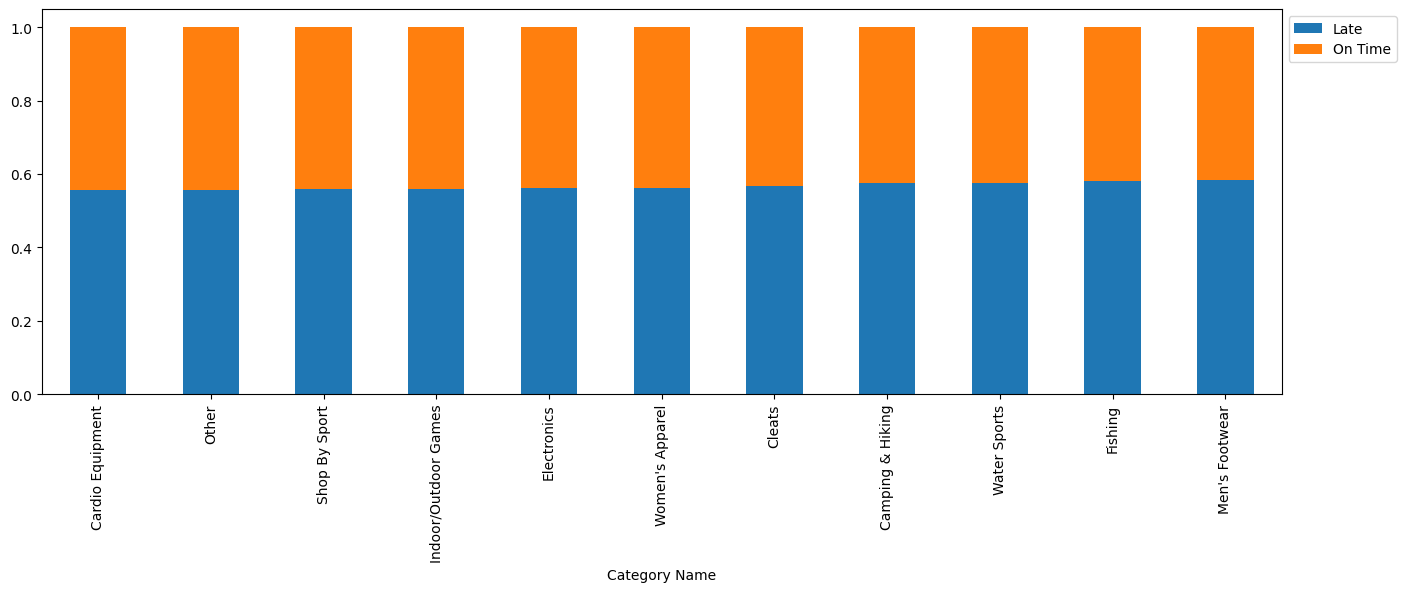

In [ ]:
stacked_barplot(delivery_df, 'Category Name', 'Delivery_outcome')

Delivery_outcome        Late   On Time
Department Name                       
Technology          0.548780  0.451220
Discs Shop          0.554522  0.445478
Outdoors            0.555856  0.444144
Footwear            0.556400  0.443600
Fitness             0.556458  0.443542
Health and Beauty   0.557746  0.442254
Golf                0.560557  0.439443
Book Shop           0.567430  0.432570
Fan Shop            0.571977  0.428023
Apparel             0.572953  0.427047
Pet Shop            0.591195  0.408805
------------------------------------------------------------------------------------------------------------------------


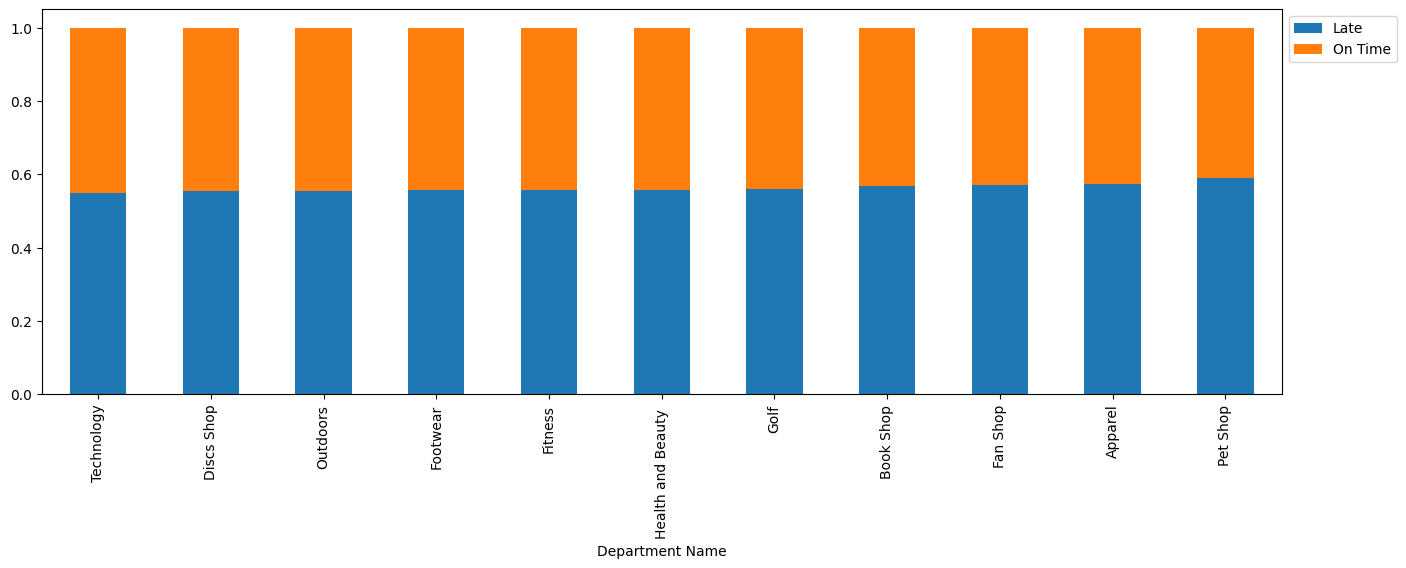

In [ ]:
stacked_barplot(delivery_df, 'Department Name', 'Delivery_outcome')

Delivery_outcome      Late   On Time
Customer Segment                    
Home Office       0.561930  0.438070
Corporate         0.566296  0.433704
Consumer          0.568996  0.431004
------------------------------------------------------------------------------------------------------------------------


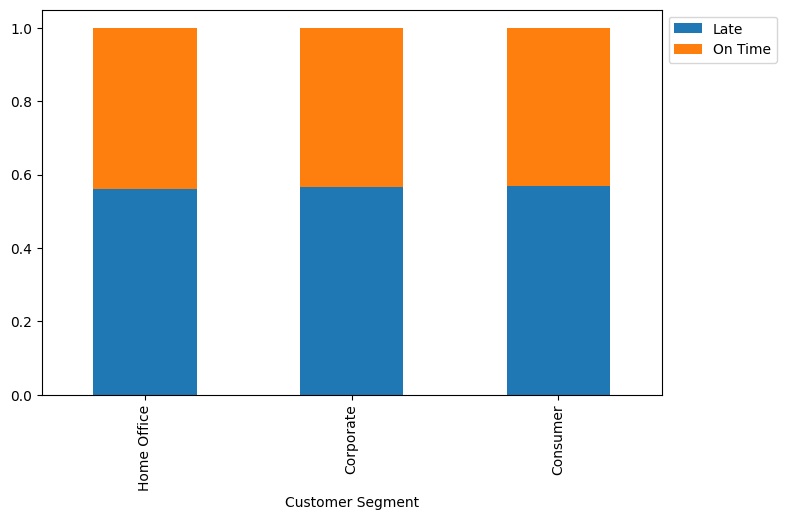

In [ ]:
stacked_barplot(delivery_df, 'Customer Segment', 'Delivery_outcome')

Delivery_outcome      Late   On Time
Customer Country                    
Puerto Rico       0.563494  0.436506
United States     0.568959  0.431041
------------------------------------------------------------------------------------------------------------------------


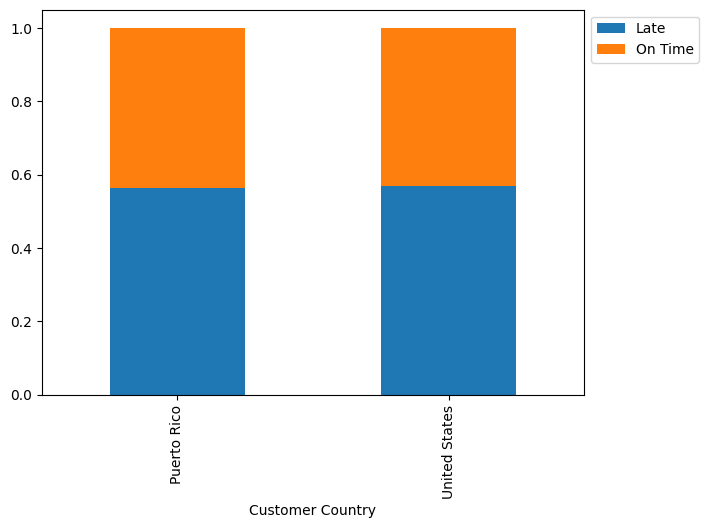

In [ ]:
stacked_barplot(delivery_df, 'Customer Country', 'Delivery_outcome')

Delivery_outcome      Late   On Time
Market                              
Africa            0.555040  0.444960
USCA              0.559043  0.440957
Pacific Asia      0.564765  0.435235
LATAM             0.571352  0.428648
Europe            0.571860  0.428140
------------------------------------------------------------------------------------------------------------------------


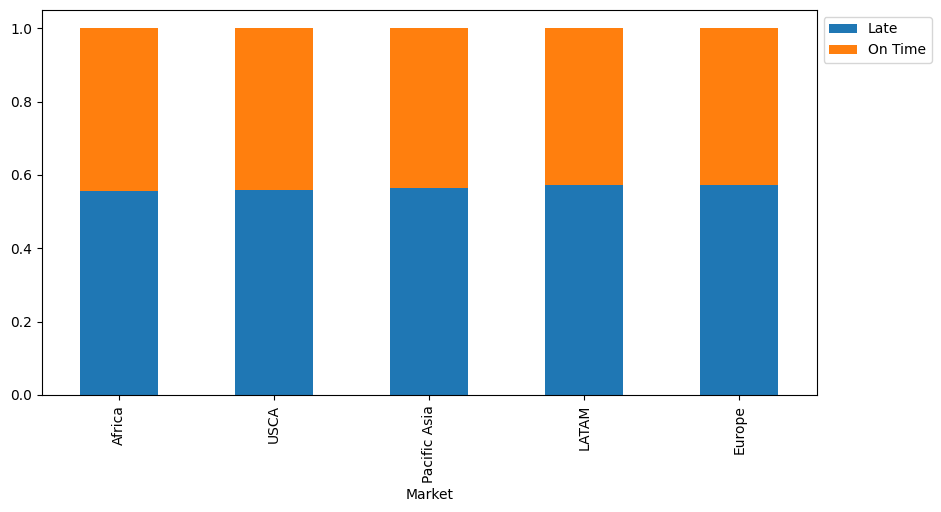

In [ ]:
stacked_barplot(delivery_df, 'Market', 'Delivery_outcome')

Delivery_outcome      Late   On Time
Order Region                        
Canada            0.490506  0.509494
Southern Africa   0.536155  0.463845
West Africa       0.541351  0.458649
Caribbean         0.550849  0.449151
Central Asia      0.554945  0.445055
West of USA       0.555252  0.444748
North Africa      0.555445  0.444555
Northern Europe   0.556234  0.443766
Oceania           0.556394  0.443606
Eastern Asia      0.559153  0.440847
Southern Europe   0.561661  0.438339
Eastern Europe    0.563403  0.436597
East of USA       0.564756  0.435244
South of  USA     0.565137  0.434863
US Center         0.565366  0.434634
East Africa       0.565753  0.434247
West Asia         0.567026  0.432974
South America     0.568696  0.431304
Southeast Asia    0.569676  0.430324
South Asia        0.573778  0.426222
Central America   0.580492  0.419508
Western Europe    0.584215  0.415785
Central Africa    0.584615  0.415385
---------------------------------------------------------------------------

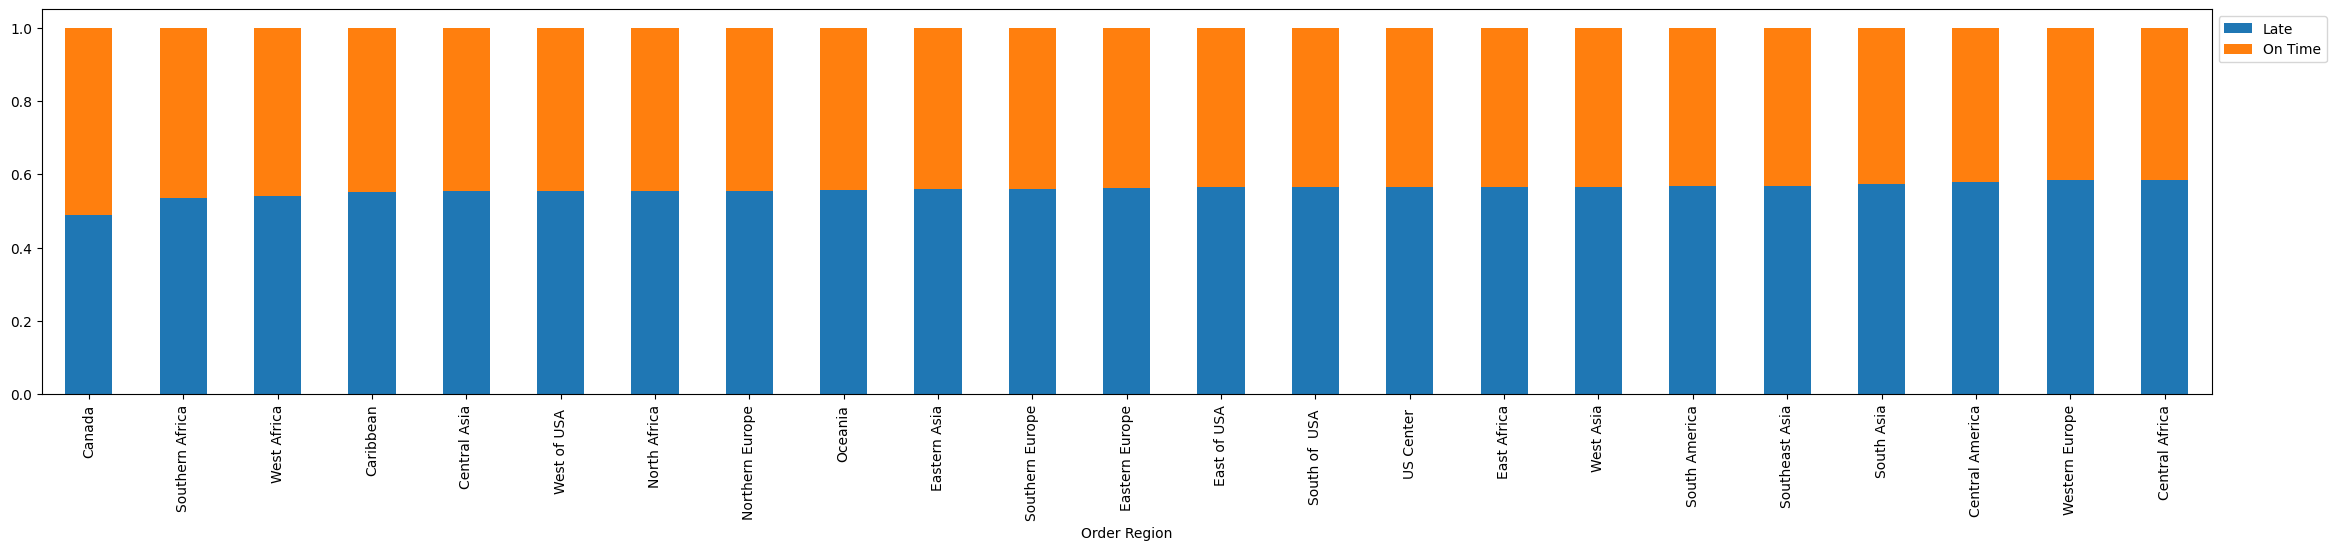

In [ ]:
stacked_barplot(delivery_df, 'Order Region', 'Delivery_outcome')

### ***Correlation Matrix of Numerical Variables***

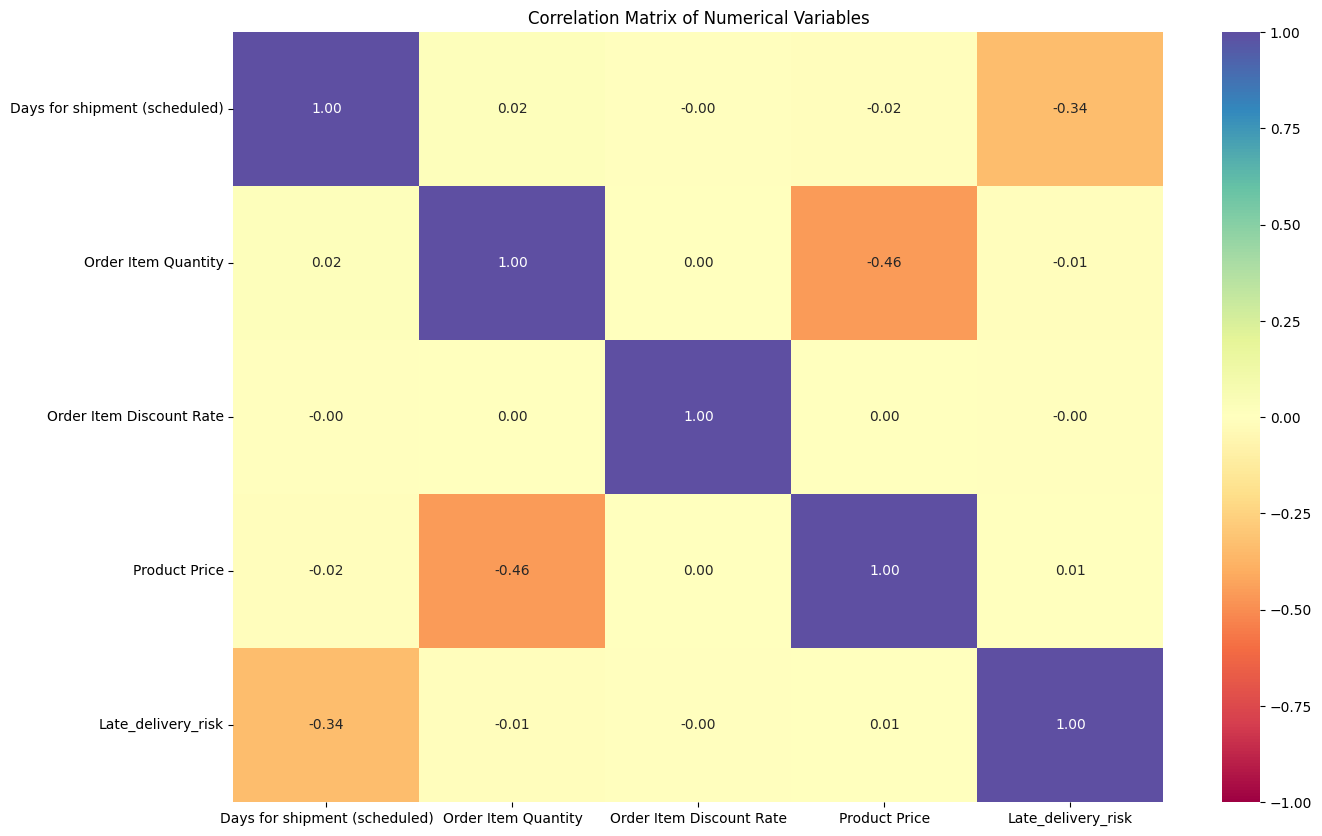

In [ ]:
plt.figure(figsize = (15, 10))
sns.heatmap(delivery_df.corr(numeric_only = True), annot = True, vmin = -1, vmax = 1, cbar = True, cmap = 'Spectral', fmt = '.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## ***Data Preprocessing***

### ***Check the percentage of outliers in the Numerical Variables***

In [ ]:
from numpy._core.defchararray import upper
Q1 = delivery_df[numerical_columns].quantile(0.25)
Q3 = delivery_df[numerical_columns].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

In [ ]:
outliers_percentage = (((delivery_df[numerical_columns] < lower_bound) | (delivery_df[numerical_columns] > upper_bound)).sum() / delivery_df.shape[0]) * 100
print(f'Percentage of outliers in the numerical variables: \n{outliers_percentage}')

Percentage of outliers in the numerical variables: 
Days for shipment (scheduled)    0.000000
Order Item Quantity              0.000000
Order Item Discount Rate         0.000000
Product Price                    1.294362
dtype: float64


### ***Handling outliers in 'Product Price' Variable***

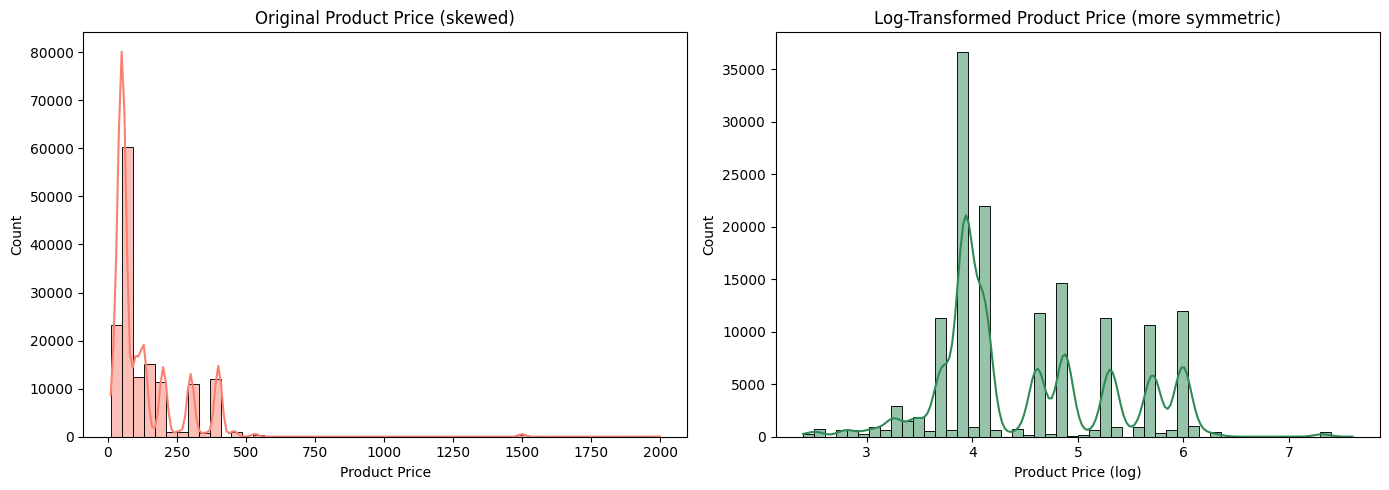

In [ ]:
delivery_df['Product Price (log)'] = np.log1p(delivery_df['Product Price'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(delivery_df['Product Price'], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Original Product Price (skewed)')

sns.histplot(delivery_df['Product Price (log)'], bins=50, kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Log-Transformed Product Price (more symmetric)')

plt.tight_layout()
plt.show()

### ***Data preparation for model building***

In [ ]:
X = delivery_df.drop(['Late_delivery_risk', 'Delivery_outcome', 'Product Price'], axis = 1)
y = delivery_df['Late_delivery_risk']

### ***Applying One-Hot Encoding to Categorical Variables***

In [ ]:
X = pd.get_dummies(X, drop_first = True)
X = X.astype(float)

### ***Splitting the dataset into Training and Test Sets***

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.3,
    random_state = 42,
    stratify = y
)

### ***Scaling Numerical Features***

In [ ]:
numerical_columns = [
    'Days for shipment (scheduled)',
    'Order Item Quantity',
    'Order Item Discount Rate',
    'Product Price (log)'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])

### ***Handling Class Imbalance with Oversampling***

In [ ]:
print("Before Oversampling, count of label 'Late': {}".format(sum(y_train == 1)))
print("Before Oversampling, count of label 'On-time': {} \n".format(sum(y_train == 0)))

sm = SMOTE(sampling_strategy = 1, k_neighbors = 5, random_state = 42)
X_train_over, y_train_over = sm.fit_resample(X_train_scaled, y_train)

print("After Oversampling, count of label 'Late': {}".format(sum(y_train_over == 1)))
print("After Oversampling, count of label 'On-time': {} \n".format(sum(y_train_over == 0)))

print("After Oversampling, the shape of X_train_over: {}".format(X_train_over.shape))
print("After Oversampling, the shape of y_train_over: {} \n".format(y_train_over.shape))

Before Oversampling, count of label 'Late': 59495
Before Oversampling, count of label 'On-time': 45475 

After Oversampling, count of label 'Late': 59495
After Oversampling, count of label 'On-time': 59495 

After Oversampling, the shape of X_train_over: (118990, 59)
After Oversampling, the shape of y_train_over: (118990,) 



## ***Model Evaluation Criteria***

In [ ]:
def model_performance_evaluation(model, predictors, target):

  """
  Function to compute different metrics to check classification model performance

  model: classifier
  predictors: independent variables
  target: dependent variable
  """

  y_pred = model.predict(predictors)

  accuracy = accuracy_score(target, y_pred)
  precision  = precision_score(target, y_pred)
  recall = recall_score(target, y_pred)
  f1 = f1_score(target, y_pred)

  df_perf = pd.DataFrame({
      'Accuracy': accuracy,
      'Precision': precision,
      'Recall': recall,
      'F1 Score': f1},
      index = [0]
      )

  return df_perf

In [ ]:
def plot_confusion_matrix(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    y_pred = model.predict(predictors)

    cm = metrics.confusion_matrix(target, y_pred)

    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## ***Model Building***

### ***Logisting Regression***

In [ ]:
logistic_regression = LogisticRegression(random_state = 42)
logistic_regression.fit(X_train_over, y_train_over)

LogisticRegression(random_state=42)

#### ***Evaluation of Model Performance on the Training Set***

In [ ]:
logistic_regression_train_perf = model_performance_evaluation(logistic_regression, X_train_over, y_train_over)
logistic_regression_train_perf

,Accuracy,Precision,Recall,F1 Score
0,0.704723,0.796019,0.550517,0.650888


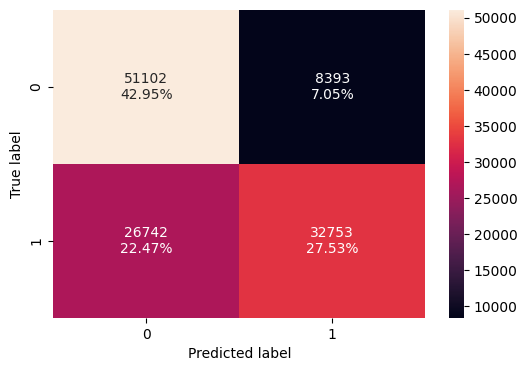

In [ ]:
plot_confusion_matrix(logistic_regression, X_train_over, y_train_over)

#### ***Evaluation of Model Performance on the Test Set***

In [ ]:
logistic_regression_test_perf = model_performance_evaluation(logistic_regression, X_test_scaled, y_test)
logistic_regression_test_perf

,Accuracy,Precision,Recall,F1 Score
0,0.684805,0.838822,0.549455,0.663981


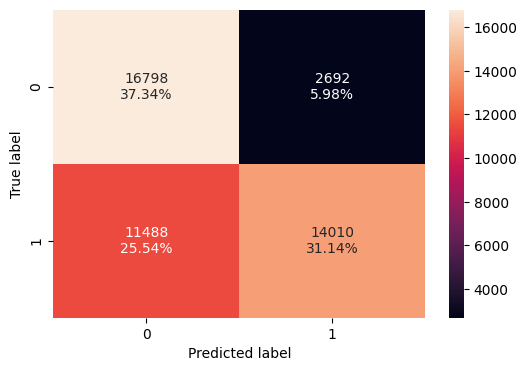

In [ ]:
plot_confusion_matrix(logistic_regression, X_test_scaled, y_test)

### ***Random Forest***

In [ ]:
%%time

random_forest_classifier = RandomForestClassifier(random_state = 42)

param_grid = {
    'n_estimators': np.arange(50, 151, 50),
    'max_depth': np.arange(5, 16, 5),
    'min_samples_split': np.arange(2, 11, 4)
}

acc_scorer = metrics.make_scorer(metrics.accuracy_score)

grid_obj = GridSearchCV(
    random_forest_classifier,
    param_grid,
    cv = 5,
    scoring = acc_scorer,
    n_jobs = -1,
    verbose = 2
)

grid_obj = grid_obj.fit(X_train_over, y_train_over)

random_forest_classifier = grid_obj.best_estimator_

random_forest_classifier.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
CPU times: user 42.1 s, sys: 22.6 s, total: 1min 4s
Wall time: 17min 53s


RandomForestClassifier(max_depth=np.int64(15), min_samples_split=np.int64(2),
                       n_estimators=np.int64(100), random_state=42)

#### ***Evaluation of Model Performance on the Training Set***

In [ ]:
random_forest_classifier_train_perf = model_performance_evaluation(random_forest_classifier, X_train_over, y_train_over)
random_forest_classifier_train_perf

,Accuracy,Precision,Recall,F1 Score
0,0.730087,0.826847,0.582066,0.683192


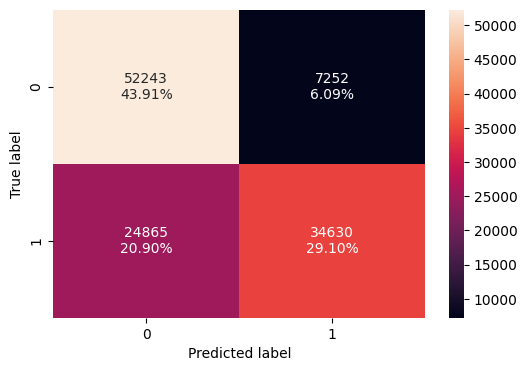

In [ ]:
plot_confusion_matrix(random_forest_classifier, X_train_over, y_train_over)

#### ***Evaluation of Model Performance on the Test Set***

In [ ]:
random_forest_classifier_test_perf = model_performance_evaluation(random_forest_classifier, X_test_scaled, y_test)
random_forest_classifier_test_perf

,Accuracy,Precision,Recall,F1 Score
0,0.685516,0.82724,0.562632,0.669748


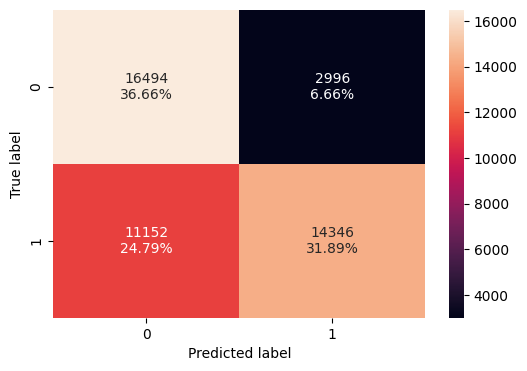

In [ ]:
plot_confusion_matrix(random_forest_classifier, X_test_scaled, y_test)

### ***XGBoost***

In [ ]:
%%time

xgboost_classifier = XGBClassifier(random_state = 42)

param_grid = {
    'n_estimators': np.arange(100, 601, 100),
    'learning_rate': np.arange(0.01, 0.31, 0.05),
    'max_depth': np.arange(3, 13, 2),
    'min_child_weight': np.arange(1, 8, 2),
    'gamma': np.arange(0, 0.6, 0.1),
    'subsample': np.arange(0.6, 1.01, 0.1),
    'colsample_bytree': np.arange(0.6, 1.01, 0.1),
    'reg_alpha': np.arange(0, 0.3, 0.1),
    'reg_lambda': np.arange(1, 4, 1)
}

acc_scorer = metrics.make_scorer(metrics.accuracy_score)

grid_obj = RandomizedSearchCV(
    xgboost_classifier,
    param_grid,
    cv = 5,
    scoring = acc_scorer,
    n_jobs = -1,
    verbose = 2,
    n_iter = 30
)

grid_obj = grid_obj.fit(X_train_over, y_train_over)

xgboost_classifier = grid_obj.best_estimator_

xgboost_classifier.fit(X_train_over, y_train_over)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
CPU times: user 37.6 s, sys: 23.4 s, total: 1min
Wall time: 24min 27s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=np.float64(0.7), device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=np.float64(0.2), grow_policy=None, importance_type=None,
              interaction_constraints=None,
              learning_rate=np.float64(0.21000000000000002), max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=np.int64(3), max_leaves=None,
              min_child_weight=np.int64(1), missing=nan,
              monotone_constraints=None, multi_strategy=None,
              n_estimators=np.int64(300), n_jobs=None, num_parallel_tree=None, ...)

#### ***Evaluation of Model Performance on the Training Set***

In [ ]:
xgboost_classifier_train_perf = model_performance_evaluation(xgboost_classifier, X_train_over, y_train_over)
xgboost_classifier_train_perf

,Accuracy,Precision,Recall,F1 Score
0,0.724817,0.822744,0.573107,0.675603


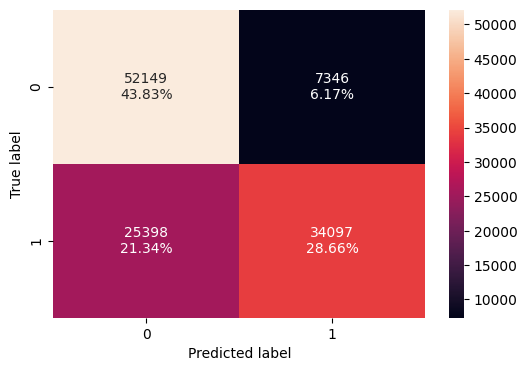

In [ ]:
plot_confusion_matrix(xgboost_classifier, X_train_over, y_train_over)

#### ***Evaluation of Model Performance on the Test Set***

In [ ]:
xgboost_classifier_test_perf = model_performance_evaluation(xgboost_classifier, X_test_scaled, y_test)
xgboost_classifier_test_perf

,Accuracy,Precision,Recall,F1 Score
0,0.683027,0.817458,0.567456,0.669892


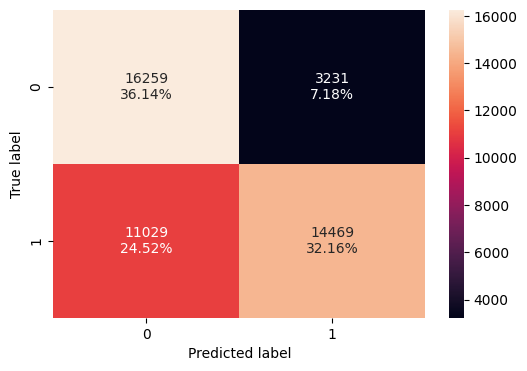

In [ ]:
plot_confusion_matrix(xgboost_classifier, X_test_scaled, y_test)

## ***Comparison of the model performance***

In [ ]:
model_performance_comparison_df = pd.concat(
    [logistic_regression_train_perf.T,
     logistic_regression_test_perf.T,
     random_forest_classifier_train_perf.T,
     random_forest_classifier_test_perf.T,
     xgboost_classifier_train_perf.T,
     xgboost_classifier_test_perf.T
    ],
    axis = 1
)

model_performance_comparison_df.columns = [
    'Logistic Regression - Train',
    'Logistic Regression - Test',
    'Random Forest - Train',
    'Random Forest - Test',
    'XGBoost - Train',
    'XGBoost - Test'
]

model_performance_comparison_df.T

,Accuracy,Precision,Recall,F1 Score
Logistic Regression - Train,0.704723,0.796019,0.550517,0.650888
Logistic Regression - Test,0.684805,0.838822,0.549455,0.663981
Random Forest - Train,0.730087,0.826847,0.582066,0.683192
Random Forest - Test,0.685516,0.827240,0.562632,0.669748
XGBoost - Train,0.724817,0.822744,0.573107,0.675603
XGBoost - Test,0.683027,0.817458,0.567456,0.669892


## ***Feature Importances of the best model***

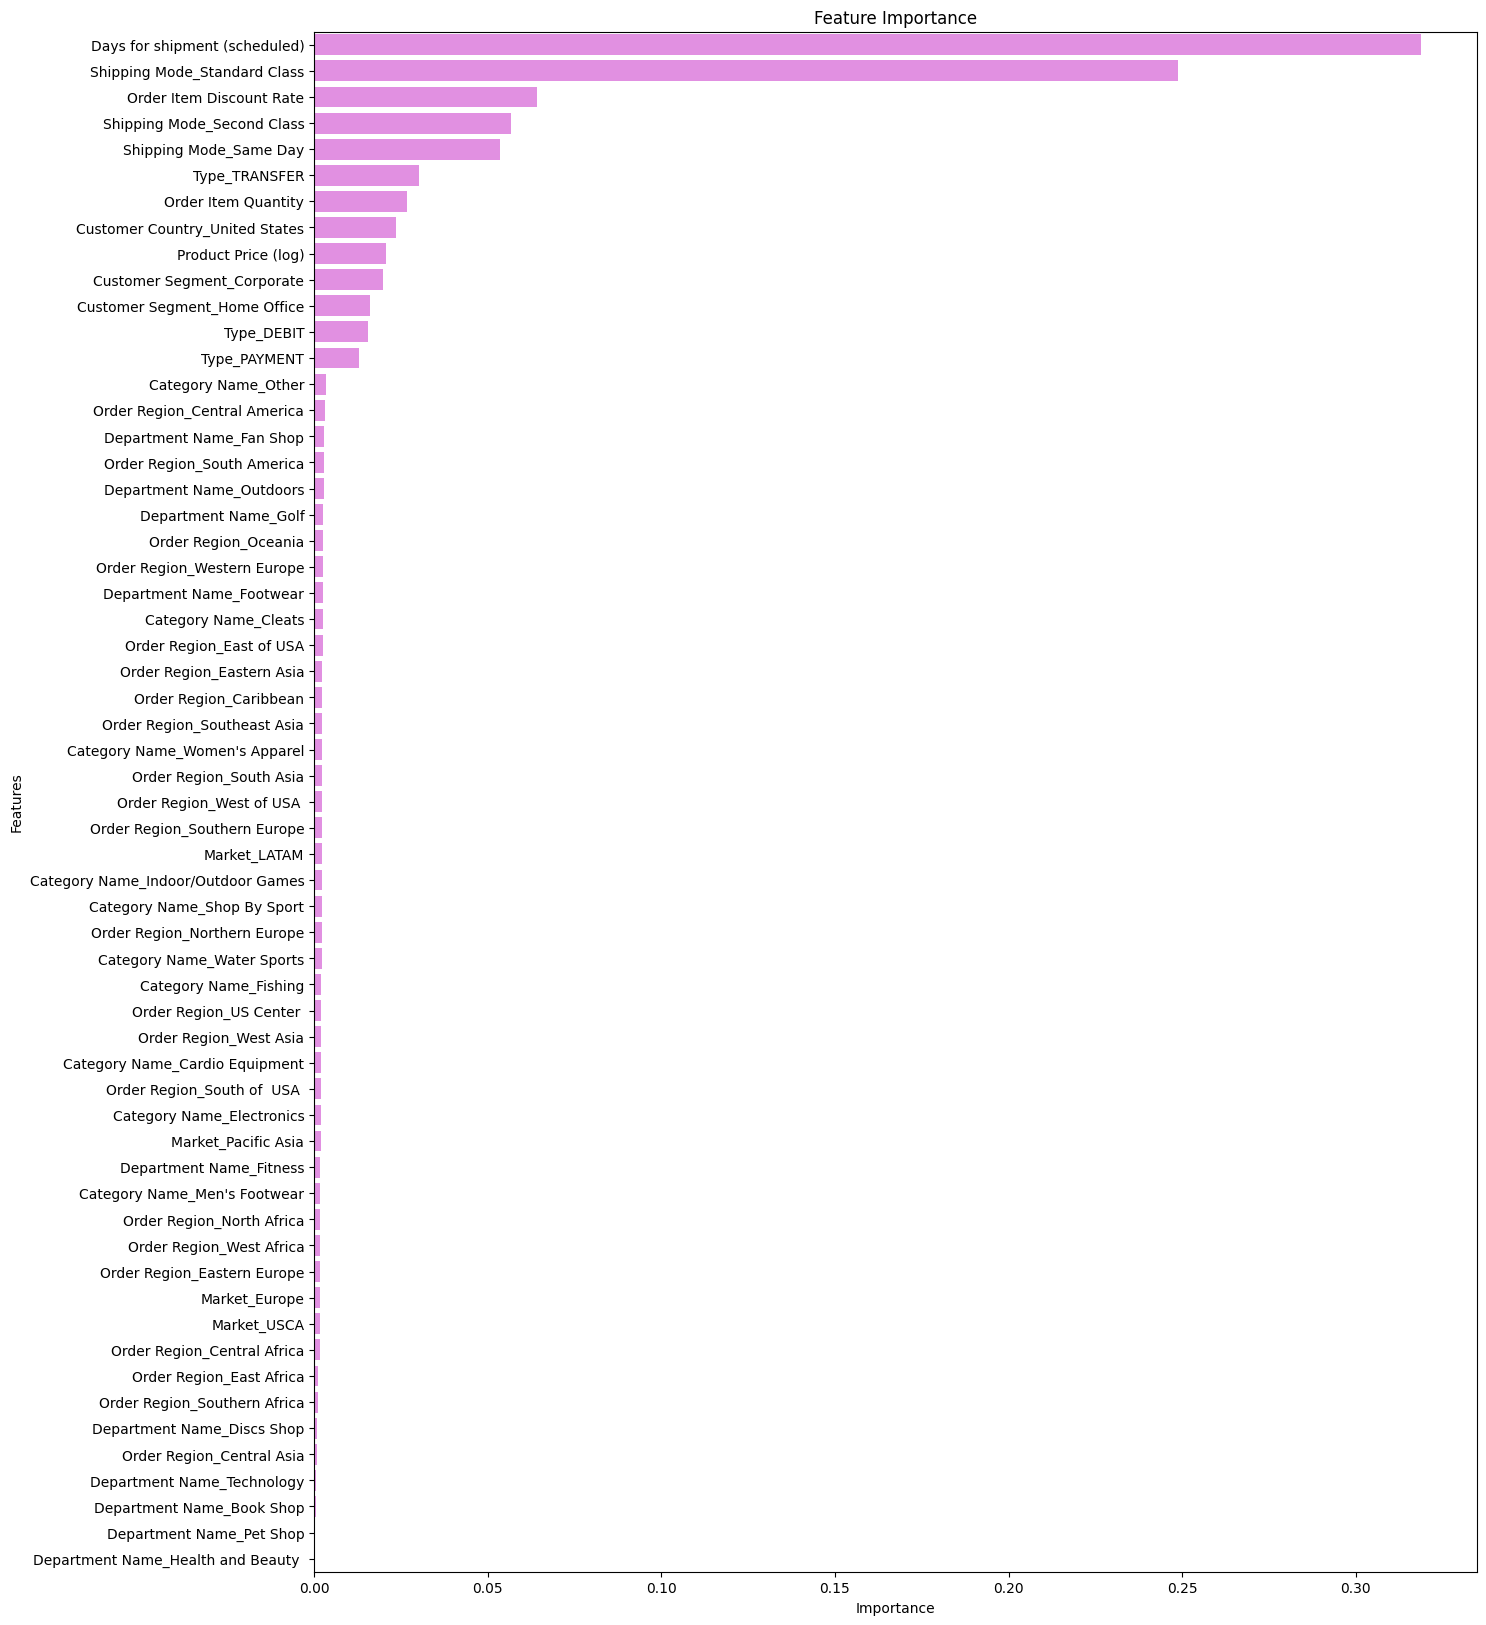

In [ ]:
feature_importances = pd.Series(random_forest_classifier.feature_importances_, index = X_train_over.columns)
feature_importances_sorted = feature_importances.sort_values(ascending = False)

plt.figure(figsize = (15, 20))
sns.barplot(x = feature_importances_sorted.values, y = feature_importances_sorted.index, color = 'violet')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()